In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")

print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:00<00:00, 334kB/s]

Extracting files...
Path to dataset files: C:\Users\admin\.cache\kagglehub\datasets\shrutimechlearn\churn-modelling\versions\1


In [82]:
import pandas as pd
import numpy as np
import os

path = r"C:\Users\admin\.cache\kagglehub\datasets\shrutimechlearn\churn-modelling\versions\1"

print(os.listdir(path))

['Churn_Modelling.csv']


In [16]:
df = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [18]:
#shape of data
df.shape


(10000, 14)

In [19]:
#check data types
df.dtypes



RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [20]:
#check unique values
df.nunique()


RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [21]:
df.isnull().values.any()


False

In [22]:
#check duplicate values
df.duplicated().sum()

0

In [23]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [24]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [25]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [27]:
print(df['Geography'].value_counts())
print(df['Gender'].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [28]:
pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
) * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [29]:
pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
) * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [30]:
pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
) * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


In [31]:
pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
) * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


In [32]:
df.groupby('Exited')[
    ['CreditScore', 'Age', 'Tenure',
     'Balance', 'NumOfProducts',
     'EstimatedSalary']
].mean()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Exited,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,1.475209,101465.677531


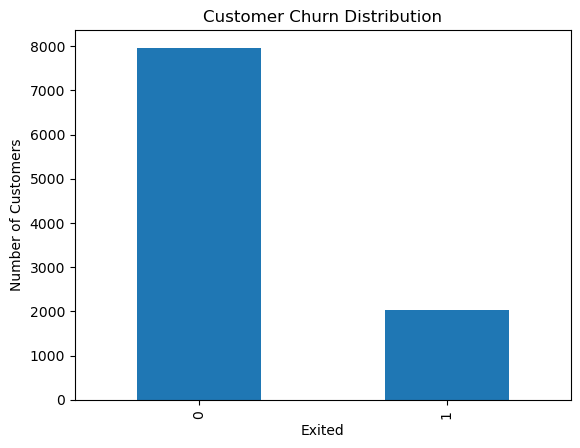

In [33]:
import matplotlib.pyplot as plt

df['Exited'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')
plt.show()

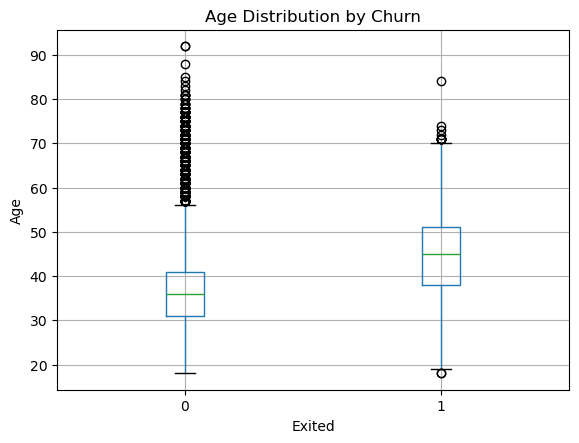

In [34]:
df.boxplot(column='Age', by='Exited')

plt.title('Age Distribution by Churn')
plt.suptitle('')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.show()

In [36]:
print(df.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [37]:
print("GEOGRAPHY")
print(pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
) * 100)

print("\nGENDER")
print(pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
) * 100)

print("\nACTIVE MEMBER")
print(pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
) * 100)

print("\nNUMBER OF PRODUCTS")
print(pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
) * 100)

GEOGRAPHY
Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395

GENDER
Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928

ACTIVE MEMBER
Exited                  0          1
IsActiveMember                      
0               73.149103  26.850897
1               85.730926  14.269074

NUMBER OF PRODUCTS
Exited                 0           1
NumOfProducts                       
1              72.285602   27.714398
2              92.418301    7.581699
3              17.293233   82.706767
4               0.000000  100.000000


In [38]:
df.groupby('Exited')[
    [
        'CreditScore',
        'Age',
        'Tenure',
        'Balance',
        'NumOfProducts',
        'EstimatedSalary'
    ]
].mean()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Exited,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,1.475209,101465.677531


In [39]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [40]:
print(X.shape)
print(y.shape)

(10000, 10)
(10000,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (8000, 10)
Test shape: (2000, 10)

Train distribution:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Test distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [52]:
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

categorical_features = [
    'Geography',
    'Gender'
]

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [54]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [55]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [56]:
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1 Score : 0.2835820895522388
ROC-AUC  : 0.7747578086561138

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Confusion Matrix:
[[1540   53]
 [ 331   76]]


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [59]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [60]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [61]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8565
Precision: 0.75
Recall   : 0.44226044226044225
F1 Score : 0.5564142194744977
ROC-AUC  : 0.8484462891242551

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1593
           1       0.75      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


Confusion Matrix:
[[1533   60]
 [ 227  180]]


In [62]:
rf_balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

In [63]:
rf_balanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [64]:
y_pred_rf_bal = rf_balanced_pipeline.predict(X_test)

y_prob_rf_bal = rf_balanced_pipeline.predict_proba(X_test)[:, 1]

In [65]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf_bal))
print("Precision:", precision_score(y_test, y_pred_rf_bal))
print("Recall   :", recall_score(y_test, y_pred_rf_bal))
print("F1 Score :", f1_score(y_test, y_pred_rf_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf_bal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_bal))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_bal))

Accuracy : 0.8605
Precision: 0.7758620689655172
Recall   : 0.44226044226044225
F1 Score : 0.5633802816901409
ROC-AUC  : 0.8507883846866898

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000


Confusion Matrix:
[[1541   52]
 [ 227  180]]


In [66]:
threshold = 0.35

y_pred_threshold = (y_prob_rf_bal >= threshold).astype(int)

In [67]:
print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

Accuracy : 0.84
Precision: 0.6153846153846154
Recall   : 0.5700245700245701
F1 Score : 0.5918367346938775

Confusion Matrix:
[[1448  145]
 [ 175  232]]


In [69]:
threshold = 0.30
y_pred_threshold = (y_prob_rf_bal >= threshold).astype(int)
print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

Accuracy : 0.829
Precision: 0.5714285714285714
Recall   : 0.6388206388206388
F1 Score : 0.6032482598607889

Confusion Matrix:
[[1398  195]
 [ 147  260]]


In [70]:
threshold = 0.40
y_pred_threshold = (y_prob_rf_bal >= threshold).astype(int)
print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

Accuracy : 0.8495
Precision: 0.6615853658536586
Recall   : 0.5331695331695332
F1 Score : 0.5904761904761905

Confusion Matrix:
[[1482  111]
 [ 190  217]]


In [71]:
# Split original training data again into train + validation
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [72]:
rf_balanced_pipeline.fit(X_train2, y_train2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [73]:
y_val_prob = rf_balanced_pipeline.predict_proba(X_val)[:, 1]

In [75]:
results = []

for threshold in np.arange(0.20, 0.61, 0.01):

    y_val_pred = (y_val_prob >= threshold).astype(int)

    results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(y_val, y_val_pred),
        'Recall': recall_score(y_val, y_val_pred),
        'F1': f1_score(y_val, y_val_pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
13,0.33,0.646104,0.610429,0.627760
12,0.32,0.631250,0.619632,0.625387
11,0.31,0.614243,0.634969,0.624434
14,0.34,0.652174,0.598160,0.624000
9,0.29,0.590659,0.659509,0.623188
15,0.35,0.663194,0.585890,0.622150
8,0.28,0.577836,0.671779,0.621277
7,0.27,0.565990,0.684049,0.619444
16,0.36,0.672662,0.573620,0.619205
10,0.30,0.597143,0.641104,0.618343


In [76]:
best_row = threshold_results.loc[
    threshold_results['F1'].idxmax()
]

best_threshold = best_row['Threshold']

print(best_row)

Threshold    0.330000
Precision    0.646104
Recall       0.610429
F1           0.627760
Name: 13, dtype: float64


In [77]:
best_threshold = 0.33

In [78]:
rf_balanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [79]:
y_test_prob = rf_balanced_pipeline.predict_proba(X_test)[:, 1]

In [80]:
y_test_pred = (y_test_prob >= best_threshold).astype(int)

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Final Threshold:", best_threshold)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Final Threshold: 0.33
Accuracy : 0.8355
Precision: 0.5965346534653465
Recall   : 0.5921375921375921
F1 Score : 0.594327990135635
ROC-AUC  : 0.8507883846866898

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.60      0.59      0.59       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000


Confusion Matrix:
[[1430  163]
 [ 166  241]]
